In [123]:
import pandas as pd

df_entsoe = pd.read_csv("data/load_hourly.csv", index_col=0, parse_dates=True)

df_Wind_CF = pd.read_csv("data/wind_cf_4zones_aggregated.csv", index_col=0)

df_PV_CF = pd.read_csv("data/pv_cf_4zones_aggregated.csv", index_col=0)

In [124]:
df_entsoe.head(3)


,Load_MW
2024-12-31 23:00:00,48221.4200
2025-01-01 00:00:00,47328.2275
2025-01-01 01:00:00,46243.6575


In [125]:
df_Wind_CF.head(3)


,Nord,West,Ost,Süd
time,,,,
2025-01-01 00:00:00,0.989543,0.749514,0.850072,0.240686
2025-01-01 01:00:00,0.992777,0.779992,0.861112,0.257526
2025-01-01 02:00:00,0.995757,0.798748,0.887177,0.277494


In [126]:
df_PV_CF.head(3)

,Nord,West,Ost,Süd
time,,,,
2025-01-01 00:00:00,0.0,0.0,0.0,0.0
2025-01-01 01:00:00,0.0,0.0,0.0,0.0
2025-01-01 02:00:00,0.0,0.0,0.0,0.0


In [127]:
weights = {
    "Nord" : 0.18,
    "West" : 0.32,
    "Ost" : 0.20,
    "Süd" : 0.30
}

load_regional = pd.DataFrame(index=df_entsoe.index)

for region, w in weights.items():
    load_regional[region] = df_entsoe.Load_MW * w

load_regional.index.name = "time"
load_regional.columns

Index(['Nord', 'West', 'Ost', 'Süd'], dtype='str')

In [128]:
load_regional.head()

,Nord,West,Ost,Süd
time,,,,
2024-12-31 23:00:00,8679.85560,15430.8544,9644.2840,14466.42600
2025-01-01 00:00:00,8519.08095,15145.0328,9465.6455,14198.46825
2025-01-01 01:00:00,8323.85835,14797.9704,9248.7315,13873.09725
2025-01-01 02:00:00,8109.32175,14416.5720,9010.3575,13515.53625
2025-01-01 03:00:00,7928.58735,14095.2664,8809.5415,13214.31225


In [129]:
""" dfs = [df_entsoe, df_Wind_CF, df_PV_CF]

results = pd.concat(dfs).to_csv("data/timeseries_2025_germany.csv") """

' dfs = [df_entsoe, df_Wind_CF, df_PV_CF]\n\nresults = pd.concat(dfs).to_csv("data/timeseries_2025_germany.csv") '

In [130]:
""" ts = pd.read_csv("data/timeseries_2025_germany.csv", index_col=0, parse_dates=True) """

' ts = pd.read_csv("data/timeseries_2025_germany.csv", index_col=0, parse_dates=True) '

In [131]:
load_regional = load_regional.iloc[1:]


In [132]:
df_Wind_CF.index[0]


'2025-01-01 00:00:00'

In [133]:
load_regional.index[0]

Timestamp('2025-01-01 00:00:00')

In [134]:
df_Wind_CF.index.equals(load_regional.index)

False

In [135]:
len(df_Wind_CF)

8760

In [136]:
len(load_regional)

8735

In [137]:
load_regional = load_regional.reindex(df_Wind_CF.index)
df_PV_CF = df_PV_CF.reindex(df_Wind_CF.index)

In [138]:
load_regional.columns = [f"load_{c}" for c in load_regional.columns]
df_Wind_CF.columns = [f"wind_{c}" for c in df_Wind_CF.columns]
df_PV_CF.columns = [f"pv_{c}" for c in df_PV_CF.columns]

In [139]:
load_regional = load_regional.interpolate()
timeseries = pd.concat([load_regional, df_Wind_CF, df_PV_CF], axis=1)



In [140]:
timeseries.head()

,load_Nord,load_West,load_Ost,load_Süd,wind_Nord,wind_West,wind_Ost,wind_Süd,pv_Nord,pv_West,pv_Ost,pv_Süd
time,,,,,,,,,,,,
2025-01-01 00:00:00,8519.08095,15145.0328,9465.6455,14198.46825,0.989543,0.749514,0.850072,0.240686,0.0,0.0,0.0,0.0
2025-01-01 01:00:00,8323.85835,14797.9704,9248.7315,13873.09725,0.992777,0.779992,0.861112,0.257526,0.0,0.0,0.0,0.0
2025-01-01 02:00:00,8109.32175,14416.5720,9010.3575,13515.53625,0.995757,0.798748,0.887177,0.277494,0.0,0.0,0.0,0.0
2025-01-01 03:00:00,7928.58735,14095.2664,8809.5415,13214.31225,0.995413,0.819556,0.911713,0.307796,0.0,0.0,0.0,0.0
2025-01-01 04:00:00,7966.97055,14163.5032,8852.1895,13278.28425,0.998344,0.822706,0.928523,0.328637,0.0,0.0,0.0,0.0


In [141]:
timeseries.columns = timeseries.columns.str.replace("load_load_", "load_")
timeseries.columns = timeseries.columns.str.replace("wind_wind_", "wind_")
timeseries.columns = timeseries.columns.str.replace("pv_pv_", "pv_")

In [143]:
timeseries.to_csv("data/timeseries_2025_germany.csv")

8760 Stunden
4 Regionen
Wind CF realistisch
PV CF realistisch
Load plausibel

In [146]:
timeseries.describe()

,load_Nord,load_West,load_Ost,load_Süd,wind_Nord,wind_West,wind_Ost,wind_Süd,pv_Nord,pv_West,pv_Ost,pv_Süd
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,9669.384839,17190.017491,10743.760932,16115.641398,0.329174,0.197543,0.178051,0.096533,0.126550,0.128981,0.127545,0.139410
std,1663.137516,2956.688917,1847.930573,2771.895860,0.234031,0.215776,0.188682,0.126691,0.189517,0.196159,0.191962,0.202208
min,6050.668410,10756.743840,6722.964900,10084.447350,0.001930,0.000006,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8301.633649,14758.459820,9224.037388,13836.056081,0.134192,0.046478,0.046343,0.019799,0.000000,0.000000,0.000000,0.000000
50%,9679.581832,17208.145480,10755.090925,16132.636387,0.280391,0.120030,0.113755,0.052337,0.001366,0.000187,0.000568,0.000993
75%,10841.515076,19273.804580,12046.127863,18069.191794,0.488070,0.266531,0.243651,0.115383,0.215504,0.215501,0.214649,0.251427
max,13752.040140,24448.071360,15280.044600,22920.066900,0.999996,0.999924,0.999803,0.817159,0.788341,0.825978,0.790769,0.831596


<Axes: xlabel='time'>

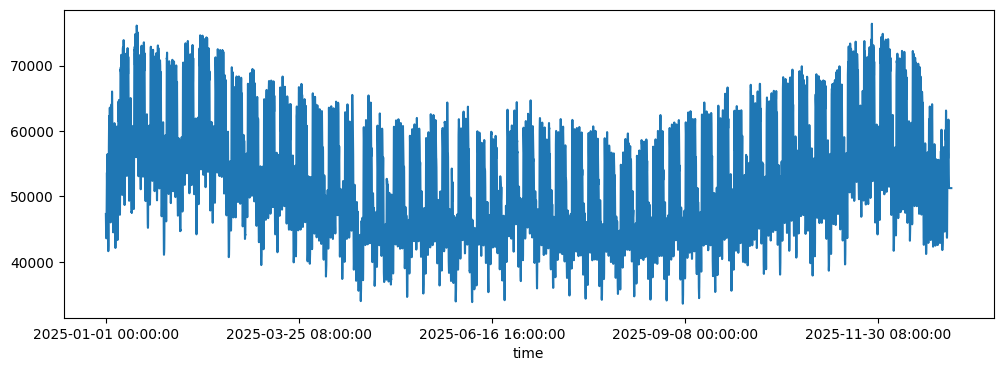

In [147]:
timeseries.filter(like="load").sum(axis=1).plot(figsize=(12,4))